# Predicting Single-to-Regular Giver Conversion using machine learning


### 1. Problem defition

Use the available data to develop a model for predicting whether a donor will convert from making a non-regular gift to becoming a regular giver within the 6-month period after their first donation (this conversion happens when a donor purchases/subscribes to a product with ‘RG’ in the product name). Your model will use the donor information available at the time of the first donation (including the information about this first donation) to make the prediction. You can frame this task as a classification problem for predicting the likelihood of conversion.

In a statement,
* Develop a classification model for predicting the likelihood of donors to convert to a regular giver.
* Based on your analysis, outline a strategy to help UNICEF Australia prioritisedonors, enabling better targeting and personalisation of marketing efforts and services, and improving their donation performance.

#  
  ### Create data dictionary
  
  1. SupporterID - Unique ID of supporter

  2. Age_Bucket - Group of age range
  
  3. Gender - Gender if known
  
  4. State - State - may be in or outside Australia
  
  5. PostCode - Postcode - may be in or outside Australia
  
  6. Have_Phone - If the donor shared their email address
  
  7. Have_Email - If the donor shared a Phone Number
  
  8. Gift_ID - Unique gift id
  
  9. GiftDate - Date of Gift
  
  10. IsEmergencyGift - Shows if the donation was in response to an emergency or disaster eg earthquake, flood etc
  
  11. Is_First_Gift - Flag if this is the donor's first gift
  
  12. ProductType_Group - Product Type shows what the donor end up donating or subscribing to
  
  13. GiftSolicitationChannel - This is the specific channel within a campaign, the method we reach out to donors like Email, Web etc
  
  14. CampaignSubType_Group - Campaign SubType shows how we reach out to the donor to communicate or ask for a donation
  
  15. AppealSeason - Appeal Season shows the time of year or season linked to the campaign
  
  16. GiftAmount - Dollar amount of the donation
  
  17. ConvertedTo_RG_Within_6M - Flag to indicate if donor converts to a Regular Giver within 6 months of their initial donation. 1 if yes, 0 if no.


## Preparing the tools

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [5]:
group = pd.read_csv('PostcodeData.csv')
test = pd.read_csv('Test_p2.csv')
data = pd.read_csv('Project2Data.csv')

In [6]:
data["PostCode"] = pd.to_numeric(data["PostCode"], errors="coerce").astype("Int64")
data["ConvertedTo_RG_Within_6M"] = pd.to_numeric(data["ConvertedTo_RG_Within_6M"], errors="coerce").astype("Int64")

# Data Processing
## Missing Value filling


In [7]:
df1 = test.copy()

col = 'Age_Bucket'
idx_unk = test.index[df1[col] == 'Unknown']
counts  = test.loc[df1[col] != 'Unknown', col].value_counts()
cats    = counts.index.to_list()
probs   = (counts / counts.sum()).reindex(cats).values

rng = np.random.default_rng(42)
choices = rng.choice(cats, size=len(idx_unk), p=probs)
test.loc[idx_unk, col] = choices
test = test.loc[test[col].notna() & (test[col] != 'Unknown')].copy()

In [8]:
df = data.copy()

col = 'Age_Bucket'
idx_unk = data.index[df[col] == 'Unknown']
counts  = data.loc[df[col] != 'Unknown', col].value_counts()
cats    = counts.index.to_list()
probs   = (counts / counts.sum()).reindex(cats).values

rng = np.random.default_rng(42)
choices = rng.choice(cats, size=len(idx_unk), p=probs)
data.loc[idx_unk, col] = choices
data = data.loc[data[col].notna() & (data[col] != 'Unknown')].copy()

In [9]:
data['Gender'] = data['Gender'].fillna('Unknown')
test['Gender'] = test['Gender'].fillna('Unknown')

In [10]:
col = 'Gender'
idx_unk = data.index[data[col] == 'Unknown']
counts  = data.loc[data[col] != 'Unknown', col].value_counts()
cats    = counts.index.to_list()
probs   = (counts / counts.sum()).reindex(cats).values

rng = np.random.default_rng(42)
choices = rng.choice(cats, size=len(idx_unk), p=probs)
data.loc[idx_unk, col] = choices
data = data.loc[data[col].notna() & (data[col] != 'Unknown')].copy()

In [11]:
col = 'Gender'
idx_unk = test.index[test[col] == 'Unknown']
counts  = test.loc[test[col] != 'Unknown', col].value_counts()
cats    = counts.index.to_list()
probs   = (counts / counts.sum()).reindex(cats).values

rng = np.random.default_rng(42)
choices = rng.choice(cats, size=len(idx_unk), p=probs)
test.loc[idx_unk, col] = choices
test = test.loc[test[col].notna() & (test[col] != 'Unknown')].copy()

In [12]:
data['IsEmergencyGift'] = np.where(data['IsEmergencyGift'] == 'Yes', 1, 0)
data['Have_Phone'] = np.where(data['Have_Phone'] == 'Yes', 1, 0)
data['Have_Email'] = np.where(data['Have_Email'] == 'Yes', 1, 0)

In [13]:
test['IsEmergencyGift'] = np.where(test['IsEmergencyGift'] == 'Yes', 1, 0)
test['Have_Phone'] = np.where(test['Have_Phone'] == 'Yes', 1, 0)
test['Have_Email'] = np.where(test['Have_Email'] == 'Yes', 1, 0)

In [14]:
test["State"] = test["State"].fillna("NA")
test["GiftSolicitationChannel"] = test["GiftSolicitationChannel"].fillna("NA")
test["PostCode"] = test["PostCode"].fillna(pd.NA)

In [15]:
data["State"] = data["State"].fillna("NA")
data["GiftSolicitationChannel"] = data["GiftSolicitationChannel"].fillna("NA")
data["PostCode"] = data["PostCode"].fillna(pd.NA)

# Filter Non RG

In [16]:
RG_product_types = [item for item in data['ProductType_Group'].unique() if isinstance(item, str) and 'RG' in item]

In [17]:
data_sorted = data.sort_values(by='SupporterID')

check postcode

In [18]:
data_sorted['State'] = data_sorted['State'].replace({'Nsw':'NSW'})
data_sorted['State'] = data_sorted['State'].replace({'Qld':'QLD'})
data_sorted['State'] = data_sorted['State'].replace({'Vic':'VIC'})
data_sorted['State'] = data_sorted['State'].replace({'Tas':'TAS'})
data_sorted['State'] = data_sorted['State'].replace({'Sa':'SA'})
data_sorted['State'] = data_sorted['State'].replace({'Wa':'WA'})
data_sorted['State'] = data_sorted['State'].replace({'Act':'ACT'})
data_sorted['State'] = data_sorted['State'].replace({'Nt':'NT'})

In [19]:
test['State'] = test['State'].replace({'Nsw':'NSW'})
test['State'] = test['State'].replace({'Qld':'QLD'})
test['State'] = test['State'].replace({'Vic':'VIC'})
test['State'] = test['State'].replace({'Tas':'TAS'})
test['State'] = test['State'].replace({'Sa':'SA'})
test['State'] = test['State'].replace({'Wa':'WA'})
test['State'] = test['State'].replace({'Act':'ACT'})
test['State'] = test['State'].replace({'Nt':'NT'})

In [20]:
postcode_ranges = {
    "NSW": [
        (1000, 2599),
        (2620, 2899),
        (2921, 2999)
    ],
    "VIC": [
        (3000, 3999),
        (8000, 8999)
    ],
    "QLD": [
        (4000, 4999),
        (9000, 9999)
    ],
    "SA": [
        (5000, 5999)
    ],
    "WA": [
        (6000, 6999)
    ],
    "TAS": [
        (7000, 7999)
    ],
    "ACT": [
        (200, 299),
        (2600, 2619),
        (2900, 2920)
    ],
    "NT": [
        (800, 999)
    ]
}

In [21]:
def get_state_from_postcode(postcode):
    for state, ranges in postcode_ranges.items():
        for low, high in ranges:
            if low <= postcode <= high:
                return state
    return None

In [22]:
# Create new column with derived state
data_sorted["derived_state"] = data_sorted["PostCode"].apply(get_state_from_postcode)

# Flag inconsistencies
data_sorted["is_inconsistent"] = data_sorted["State"] != data_sorted["derived_state"]

# Count the number of inconsistent rows
inconsistent_count_df = data_sorted[data_sorted["is_inconsistent"] == True].shape[0]
print(f"Number of inconsistent rows: {inconsistent_count_df}")

Number of inconsistent rows: 107192


In [23]:
test["derived_state"] = test["PostCode"].apply(get_state_from_postcode)
test["is_inconsistent"] = test["State"] != test["derived_state"]
inconsistent_count_test = test[test["is_inconsistent"] == True].shape[0]
print(f"Number of inconsistent rows: {inconsistent_count_test}")

Number of inconsistent rows: 2761


这 暂时是给eda, model 用不上

# Mosaic Group Merge

In [24]:
# Merge data_unique_supporters with group based on PostCode to get DOMINANT_MOSAIC_GROUP
data_sorted = pd.merge(
    data_sorted,
    group[['POSTCODE', 'DOMINANT_MOSAIC_GROUP','DOMINANT_MOSAIC_TYPE']],
    left_on='PostCode',
    right_on='POSTCODE',
    how='left'
)

# Drop the redundant POSTCODE column from the merge
data_sorted.drop(columns=['POSTCODE'], inplace=True)

In [25]:
test = pd.merge(
    test,
    group[['POSTCODE', 'DOMINANT_MOSAIC_GROUP','DOMINANT_MOSAIC_TYPE']],
    left_on='PostCode',
    right_on='POSTCODE',
    how='left')

test.drop(columns=['POSTCODE'], inplace=True)

In [26]:
data_sorted.drop(columns=['State', 'is_inconsistent'], inplace=True)
data_sorted['derived_state'] = data_sorted['derived_state'].fillna('is_inconsistent')
data_sorted['DOMINANT_MOSAIC_GROUP'] = data_sorted['DOMINANT_MOSAIC_GROUP'].fillna('Unknown')
data_sorted['DOMINANT_MOSAIC_TYPE'] = data_sorted['DOMINANT_MOSAIC_TYPE'].fillna('Unknown')

In [27]:
test.drop(columns=['State', 'is_inconsistent'], inplace=True)
test['derived_state'] = test['derived_state'].fillna('is_inconsistent')
test['DOMINANT_MOSAIC_GROUP'] = test['DOMINANT_MOSAIC_GROUP'].fillna('Unknown')
test['DOMINANT_MOSAIC_TYPE'] = test['DOMINANT_MOSAIC_TYPE'].fillna('Unknown')

In [28]:
gift_counts = data_sorted.groupby('SupporterID')['Gift_ID'].count()
data_sorted = data_sorted.merge(gift_counts.rename('GiftCount'), on='SupporterID')

data_sorted

,SupporterID,Age_Bucket,Gender,PostCode,Have_Phone,Have_Email,Gift_ID,GiftDate,IsEmergencyGift,Is_First_Gift,ProductType_Group,GiftSolicitationChannel,CampaignSubtype_Group,AppealSeason,GiftAmount,ConvertedTo_RG_Within_6M,derived_state,DOMINANT_MOSAIC_GROUP,DOMINANT_MOSAIC_TYPE,GiftCount
0,A-990430482,71+,Male,2166,0,0,0062u00000AFwB5AAL,2020-11-04,0,Is_First_Gift,Cash - One off,Web,Appeal,Non Seasonal,56.0,0,NSW,F,F20,1
1,A-990434539,41-50,Female,2027,0,0,0062u00000AZ70jAAD,2020-12-03,0,Is_First_Gift,Cash - One off,DM,Appeal,Christmas,140.0,0,NSW,B,B06,1
2,A-990435870,61-70,Male,<NA>,0,0,0062u00000Aa42AAAR,2020-12-16,0,Is_First_Gift,Cash - Inspired Gifts,DM,Appeal,Non Seasonal,70.0,0,is_inconsistent,Unknown,Unknown,1
3,A-990435901,71+,Male,<NA>,0,0,0062u00000Aa997AAB,2020-12-17,0,Is_First_Gift,Cash - One off,General,Appeal,Non Seasonal,35.0,0,is_inconsistent,Unknown,Unknown,1
4,C-990018085,31-40,Female,3144,0,0,0062u000009YQXHAA4,2015-05-11,1,Is_First_Gift,Cash - One off,Inserts,Appeal,Non Seasonal,175.0,0,VIC,A,A01,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1780135,N_990621275,71+,Female,3008,1,1,0062u00000AEnGoAAL,2020-10-16,0,Is_First_Gift,Community Fundraising,NA,Community Fundraising,Non Seasonal,70.0,0,VIC,G,B07,1
1780136,N_990621277,41-50,Male,3174,1,1,0062u00000DCmPSAA1,2021-10-05,0,Not_First_Gift,Cash - One off,Web,Appeal,Non Seasonal,7.0,0,VIC,H,H27,4
1780137,N_990621277,31-40,Male,3174,1,1,0068v000002X5VjAAK,2023-01-16,1,Not_First_Gift,Cash - One off,Web,Appeal,Non Seasonal,7.0,0,VIC,H,H27,4
1780138,N_990621277,41-50,Female,3174,1,1,0062u00000ADfutAAD,2020-10-03,0,Is_First_Gift,Cash - One off,Web,Appeal,Non Seasonal,7.0,0,VIC,H,H27,4


In [29]:
test_counts = test.groupby('SupporterID')['Gift_ID'].count()
test = test.merge(test_counts.rename('GiftCount'), on='SupporterID')

test

,SupporterID,Age_Bucket,Gender,PostCode,Have_Phone,Have_Email,Gift_ID,GiftDate,IsEmergencyGift,Is_First_Gift,ProductType_Group,GiftSolicitationChannel,CampaignSubtype_Group,AppealSeason,GiftAmount,derived_state,DOMINANT_MOSAIC_GROUP,DOMINANT_MOSAIC_TYPE,GiftCount
0,C-990078102,61-70,Male,2088.0,0,0,0062u000009SyPiAAK,8/01/2014,1,Is_First_Gift,Cash - One off,Web,Appeal,Non Seasonal,70.0,NSW,A,A01,1
1,C-990116708,41-50,Female,5006.0,0,0,0062u000009FmpmAAC,4/27/2015,1,Is_First_Gift,Cash - One off,Web,Appeal,Non Seasonal,35.0,SA,I,I28,1
2,C-990132428,61-70,Female,4007.0,1,1,0062u000009SLdHAAW,9/02/2015,0,Is_First_Gift,Cash - Inspired Gifts,Web,Appeal,Non Seasonal,28.0,QLD,B,B07,1
3,C-990137490,51-60,Female,NaN,1,1,0062u00000C4UWoAAN,4/29/2021,1,Is_First_Gift,Cash - One off,EDM,Appeal,Non Seasonal,576.1,is_inconsistent,Unknown,Unknown,1
4,C-990189756,31-40,Male,2777.0,1,1,0062u00000DC1KSAA1,9/04/2021,0,Is_First_Gift,Cash - Inspired Gifts,EDM,Appeal,Non Seasonal,42.0,NSW,D,D13,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15219,N_990621183,41-50,Male,2300.0,1,1,0062u00000C5RabAAF,5/11/2021,1,Is_First_Gift,Cash - One off,Web,Appeal,Non Seasonal,35.0,NSW,B,B07,1
15220,N_990621184,71+,Female,NaN,1,1,0062u000009gBTKAA2,8/07/2020,1,Is_First_Gift,Cash - One off,Web,Appeal,Non Seasonal,61.6,is_inconsistent,Unknown,Unknown,1
15221,N_990621235,31-40,Female,2060.0,1,1,0062u00000Bble2AAB,3/15/2021,1,Is_First_Gift,Cash - One off,General,Appeal,Non Seasonal,147.0,NSW,B,B06,1
15222,N_990621240,31-40,Female,2077.0,1,1,0062u00000BbzCZAAZ,3/17/2021,0,Is_First_Gift,Cash - One off,Web,Appeal,Non Seasonal,107.1,NSW,E,E16,1


# FirstGift

In [30]:
data_fg = data_sorted[data_sorted['Is_First_Gift'] == 'Is_First_Gift']
df_train = data_fg[~data_fg['ProductType_Group'].isin(RG_product_types)].copy()

df_train

,SupporterID,Age_Bucket,Gender,PostCode,Have_Phone,Have_Email,Gift_ID,GiftDate,IsEmergencyGift,Is_First_Gift,ProductType_Group,GiftSolicitationChannel,CampaignSubtype_Group,AppealSeason,GiftAmount,ConvertedTo_RG_Within_6M,derived_state,DOMINANT_MOSAIC_GROUP,DOMINANT_MOSAIC_TYPE,GiftCount
0,A-990430482,71+,Male,2166,0,0,0062u00000AFwB5AAL,2020-11-04,0,Is_First_Gift,Cash - One off,Web,Appeal,Non Seasonal,56.0,0,NSW,F,F20,1
1,A-990434539,41-50,Female,2027,0,0,0062u00000AZ70jAAD,2020-12-03,0,Is_First_Gift,Cash - One off,DM,Appeal,Christmas,140.0,0,NSW,B,B06,1
2,A-990435870,61-70,Male,<NA>,0,0,0062u00000Aa42AAAR,2020-12-16,0,Is_First_Gift,Cash - Inspired Gifts,DM,Appeal,Non Seasonal,70.0,0,is_inconsistent,Unknown,Unknown,1
3,A-990435901,71+,Male,<NA>,0,0,0062u00000Aa997AAB,2020-12-17,0,Is_First_Gift,Cash - One off,General,Appeal,Non Seasonal,35.0,0,is_inconsistent,Unknown,Unknown,1
4,C-990018085,31-40,Female,3144,0,0,0062u000009YQXHAA4,2015-05-11,1,Is_First_Gift,Cash - One off,Inserts,Appeal,Non Seasonal,175.0,0,VIC,A,A01,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1780132,N_990621270,19 - 30,Female,2212,1,1,0062u000009gjx5AAA,2020-08-18,1,Is_First_Gift,Cash - One off,Web,Appeal,Spring,52.5,0,NSW,C,C10,1
1780133,N_990621271,41-50,Female,3194,1,1,0062u000009hsXnAAI,2020-09-01,1,Is_First_Gift,Cash - One off,Web,Appeal,Spring,105.0,0,VIC,I,I30,1
1780134,N_990621272,51-60,Female,3075,1,1,0062u000009fhr5AAA,2020-08-06,1,Is_First_Gift,Cash - One off,Web,Appeal,Non Seasonal,7.0,0,VIC,J,J31,1
1780135,N_990621275,71+,Female,3008,1,1,0062u00000AEnGoAAL,2020-10-16,0,Is_First_Gift,Community Fundraising,NA,Community Fundraising,Non Seasonal,70.0,0,VIC,G,B07,1


# GiftAmount Distribution & Outlier

In [31]:
df_train['GiftAmount'].describe()

,GiftAmount
count,135627.000000
mean,80.595704
std,227.360911
min,-0.070000
25%,21.000000
50%,35.700000
75%,70.000000
max,17500.000000


In [32]:
# gift amount cannot be negative, remove the false record.
df_train = df_train[df_train['GiftAmount'] >= 0].copy()
display(df_train['GiftAmount'].describe())

,GiftAmount
count,135626.000000
mean,80.596299
std,227.361644
min,0.030000
25%,21.000000
50%,35.700000
75%,70.000000
max,17500.000000


# Feature engineering

## GiftamountLog

In [33]:
# Apply log transformation to GiftAmount
df_train['GiftAmount_log'] = np.log1p(df_train['GiftAmount'])
test['GiftAmount_log'] = np.log1p(test['GiftAmount'])

## HighValue

In [34]:
amt_med = df_train["GiftAmount"].median()
df_train["high_value"]=(df_train["GiftAmount"]> amt_med).astype(int)
test["high_value"]=(test["GiftAmount"]> amt_med).astype(int)

## contact & high value

In [35]:
df_train["has_contact"] =((df_train["Have_Phone"] == 1)| (df_train["Have_Email"] == 1)).astype(int)
test["has_contact"] =((test["Have_Phone"] == 1)| (test["Have_Email"] == 1)).astype(int)
df_train["HighValue_has_contact"]=((df_train["GiftAmount"]> df_train["GiftAmount"].median())& (df_train["has_contact"] == 1)).astype(int)
test["HighValue_has_contact"]=((test["GiftAmount"]> test["GiftAmount"].median())& (test["has_contact"] == 1)).astype(int)

## digital channel

In [36]:
digital_set= {"Web" , "EDM" ,"Telemarketing" ,"TV","DRTV","SMS"}
df_train["chan_digital"]= df["GiftSolicitationChannel"].isin(digital_set).astype(int)
test["chan_digital"]= test["GiftSolicitationChannel"].isin(digital_set).astype(int)

## digital & Emergency

In [37]:
df_train["Digital_Emergency"] = (df_train["chan_digital"] & df_train["IsEmergencyGift"]).astype(int)
df_train["Highvalue_Digital"]= (df_train["high_value"] & df_train["chan_digital"]).astype(int)
test["Digital_Emergency"] = (test["chan_digital"] & test["IsEmergencyGift"]).astype(int)
test["Highvalue_Digital"]= (test["high_value"] & test["chan_digital"]).astype(int)

In [38]:
test['Gender'].unique()

array(['Male', 'Female'], dtype=object)

## digital & contact




In [39]:
df_train["Digital_contact"] = (df_train["chan_digital"] & df_train["has_contact"]).astype(int)
test["Digital_contact"] = (test["chan_digital"] & test["has_contact"]).astype(int)

## Gender & Age

In [40]:
#gender
df_train["Male"] = (df_train["Gender"] == 'Male').astype(int)
test["Male"] = (test["Gender"] == 'Male').astype(int)
df_train["Female"] = (df_train["Gender"] == 'Female').astype(int)
test["Female"] = (test["Gender"] == 'Female').astype(int)

#age
df_train["young"] = ((df_train["Age_Bucket"] == '19-30') | (df_train["Age_Bucket"] == '31-40')).astype(int)
test["young"] = ((test["Age_Bucket"] == '19-30') | (test["Age_Bucket"] == '31-40')).astype(int)
df_train["midage"] = ((df_train["Age_Bucket"] == '41-50') | (df_train["Age_Bucket"] == '51-60')).astype(int)
test["midage"] = ((test["Age_Bucket"] == '41-50') | (test["Age_Bucket"] == '51-60')).astype(int)
df_train["elder"] = ((df_train["Age_Bucket"] == '61-70') | (df_train["Age_Bucket"] == '71+')).astype(int)
test["elder"] = ((test["Age_Bucket"] == '61-70') | (test["Age_Bucket"] == '71+')).astype(int)

# gender * age
df_train["Male_young"] = (df_train["Male"] & df_train["young"]).astype(int)
test["Male_young"] = (test["Male"] & test["young"]).astype(int)
df_train["Male_midage"] = (df_train["Male"] & df_train["midage"]).astype(int)
test["Male_midage"] = (test["Male"] & test["midage"]).astype(int)
df_train["Male_elder"] = (df_train["Male"] & df_train["elder"]).astype(int)
test["Male_elder"] = (test["Male"] & test["elder"]).astype(int)
df_train["Female_young"] = (df_train["Female"] & df_train["young"]).astype(int)
test["Female_young"] = (test["Female"] & test["young"]).astype(int)
df_train["Female_midage"] = (df_train["Female"] & df_train["midage"]).astype(int)
test["Female_midage"] = (test["Female"] & test["midage"]).astype(int)
df_train["Female_elder"] = (df_train["Female"] & df_train["elder"]).astype(int)
test["Female_elder"] = (test["Female"] & test["elder"]).astype(int)

In [41]:
df_train['highvalue_count'] = df_train['high_value']*df_train['GiftCount']
test['highvalue_count'] = test['high_value']*test['GiftCount']

In [42]:
df_train['contact_count'] = df_train['has_contact']*df_train['GiftCount']
test['contact_count'] = test['has_contact']*test['GiftCount']

In [43]:
df_train['highvalue_Male']=(df_train["high_value"] | (df_train["Gender"] == 'Male')).astype(int)
df_train['highvalue_Female']=(df_train["high_value"] | (df_train["Gender"] == 'Female')).astype(int)

## Digital & age

In [44]:
df_train['young_digital'] = (df_train["chan_digital"] & df_train["young"]).astype(int)
test['young_digital'] = (test["chan_digital"] & test["young"]).astype(int)
df_train['midage_digital'] = (df_train["chan_digital"] & df_train["midage"]).astype
test['midage_digital'] = (test["chan_digital"] & test["midage"]).astype
df_train['elder_digital'] = (df_train["chan_digital"] & df_train["elder"]).astype(int)
test['elder_digital'] = (test["chan_digital"] & test["elder"]).astype(int)

In [45]:
df_train['young_digital_contact']= (df_train["young_digital"] & df_train["has_contact"]).astype(int)
test['young_digital_contact']= (test["young_digital"] & test["has_contact"]).astype(int)

In [46]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15224 entries, 0 to 15223
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   SupporterID              15224 non-null  object 
 1   Age_Bucket               15224 non-null  object 
 2   Gender                   15224 non-null  object 
 3   PostCode                 12509 non-null  float64
 4   Have_Phone               15224 non-null  int64  
 5   Have_Email               15224 non-null  int64  
 6   Gift_ID                  15224 non-null  object 
 7   GiftDate                 15224 non-null  object 
 8   IsEmergencyGift          15224 non-null  int64  
 9   Is_First_Gift            15224 non-null  object 
 10  ProductType_Group        15224 non-null  object 
 11  GiftSolicitationChannel  15224 non-null  object 
 12  CampaignSubtype_Group    15224 non-null  object 
 13  AppealSeason             15224 non-null  object 
 14  GiftAmount            

In [47]:
test

,SupporterID,Age_Bucket,Gender,PostCode,Have_Phone,Have_Email,Gift_ID,GiftDate,IsEmergencyGift,Is_First_Gift,...,Male_elder,Female_young,Female_midage,Female_elder,highvalue_count,contact_count,young_digital,midage_digital,elder_digital,young_digital_contact
0,C-990078102,61-70,Male,2088.0,0,0,0062u000009SyPiAAK,8/01/2014,1,Is_First_Gift,...,1,0,0,0,1,0,0,<bound method NDFrame.astype of 0 0\n1 ...,1,0
1,C-990116708,41-50,Female,5006.0,0,0,0062u000009FmpmAAC,4/27/2015,1,Is_First_Gift,...,0,0,1,0,0,0,0,<bound method NDFrame.astype of 0 0\n1 ...,0,0
2,C-990132428,61-70,Female,4007.0,1,1,0062u000009SLdHAAW,9/02/2015,0,Is_First_Gift,...,0,0,0,1,0,1,0,<bound method NDFrame.astype of 0 0\n1 ...,1,0
3,C-990137490,51-60,Female,NaN,1,1,0062u00000C4UWoAAN,4/29/2021,1,Is_First_Gift,...,0,0,1,0,1,1,0,<bound method NDFrame.astype of 0 0\n1 ...,0,0
4,C-990189756,31-40,Male,2777.0,1,1,0062u00000DC1KSAA1,9/04/2021,0,Is_First_Gift,...,0,0,0,0,1,1,1,<bound method NDFrame.astype of 0 0\n1 ...,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15219,N_990621183,41-50,Male,2300.0,1,1,0062u00000C5RabAAF,5/11/2021,1,Is_First_Gift,...,0,0,0,0,0,1,0,<bound method NDFrame.astype of 0 0\n1 ...,0,0
15220,N_990621184,71+,Female,NaN,1,1,0062u000009gBTKAA2,8/07/2020,1,Is_First_Gift,...,0,0,0,1,1,1,0,<bound method NDFrame.astype of 0 0\n1 ...,1,0
15221,N_990621235,31-40,Female,2060.0,1,1,0062u00000Bble2AAB,3/15/2021,1,Is_First_Gift,...,0,1,0,0,1,1,0,<bound method NDFrame.astype of 0 0\n1 ...,0,0
15222,N_990621240,31-40,Female,2077.0,1,1,0062u00000BbzCZAAZ,3/17/2021,0,Is_First_Gift,...,0,1,0,0,1,1,1,<bound method NDFrame.astype of 0 0\n1 ...,0,1


In [48]:
df_train

,SupporterID,Age_Bucket,Gender,PostCode,Have_Phone,Have_Email,Gift_ID,GiftDate,IsEmergencyGift,Is_First_Gift,...,Female_midage,Female_elder,highvalue_count,contact_count,highvalue_Male,highvalue_Female,young_digital,midage_digital,elder_digital,young_digital_contact
0,A-990430482,71+,Male,2166,0,0,0062u00000AFwB5AAL,2020-11-04,0,Is_First_Gift,...,0,0,1,0,1,1,0,<bound method NDFrame.astype of 0 0\n...,1,0
1,A-990434539,41-50,Female,2027,0,0,0062u00000AZ70jAAD,2020-12-03,0,Is_First_Gift,...,1,0,1,0,1,1,0,<bound method NDFrame.astype of 0 0\n...,0,0
2,A-990435870,61-70,Male,<NA>,0,0,0062u00000Aa42AAAR,2020-12-16,0,Is_First_Gift,...,0,0,1,0,1,1,0,<bound method NDFrame.astype of 0 0\n...,0,0
3,A-990435901,71+,Male,<NA>,0,0,0062u00000Aa997AAB,2020-12-17,0,Is_First_Gift,...,0,0,0,0,1,0,0,<bound method NDFrame.astype of 0 0\n...,0,0
4,C-990018085,31-40,Female,3144,0,0,0062u000009YQXHAA4,2015-05-11,1,Is_First_Gift,...,0,0,2,0,1,1,0,<bound method NDFrame.astype of 0 0\n...,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1780132,N_990621270,19 - 30,Female,2212,1,1,0062u000009gjx5AAA,2020-08-18,1,Is_First_Gift,...,0,0,1,1,1,1,0,<bound method NDFrame.astype of 0 0\n...,0,0
1780133,N_990621271,41-50,Female,3194,1,1,0062u000009hsXnAAI,2020-09-01,1,Is_First_Gift,...,1,0,1,1,1,1,0,<bound method NDFrame.astype of 0 0\n...,0,0
1780134,N_990621272,51-60,Female,3075,1,1,0062u000009fhr5AAA,2020-08-06,1,Is_First_Gift,...,1,0,0,1,0,1,0,<bound method NDFrame.astype of 0 0\n...,0,0
1780135,N_990621275,71+,Female,3008,1,1,0062u00000AEnGoAAL,2020-10-16,0,Is_First_Gift,...,0,1,1,1,1,1,0,<bound method NDFrame.astype of 0 0\n...,0,0


In [49]:
np.sum(df_train['Highvalue_Digital'] == 1)

np.int64(53652)

In [50]:
# df_train["Emergency_EmailDonor"]=((df_train["IsEmergencyGift"].str.lower().eq("yes"))&(df_train["Have_Email"].str.lower().eq("yes"))).astype(int)

In [51]:
xdf_train = df_train.copy()
xdf_train = xdf_train[['Gender','Age_Bucket',
                       'has_contact','IsEmergencyGift',
                       'ProductType_Group','AppealSeason','GiftAmount_log',
                       'GiftSolicitationChannel','CampaignSubtype_Group','DOMINANT_MOSAIC_GROUP',
                       'ConvertedTo_RG_Within_6M']]

In [52]:
xdf_train = pd.get_dummies(xdf_train, dummy_na=True, drop_first=True).fillna(0)

In [53]:
X_train = xdf_train.drop(columns=['ConvertedTo_RG_Within_6M'])
y_train = xdf_train['ConvertedTo_RG_Within_6M']

# Data Exploration (Exploratory data analysis or EDA)


SHAP交互分析

计算SHAP交互值（样本数=1000）...

=== Top 30 交互特征（SHAP） ===
                               feature1                                feature2  interaction_strength
            GiftSolicitationChannel_Web           DOMINANT_MOSAIC_GROUP_Unknown              0.036276
                         GiftAmount_log                             Gender_Male              0.034307
                            has_contact                          GiftAmount_log              0.034160
                         GiftAmount_log                        Age_Bucket_51-60              0.031412
ProductType_Group_Community Fundraising              GiftSolicitationChannel_NA              0.031220
                        IsEmergencyGift                          GiftAmount_log              0.030651
                         GiftAmount_log                        Age_Bucket_31-40              0.030210
                         GiftAmount_log           DOMINANT_MOSAIC_GROUP_Unknown              0.028952
                     

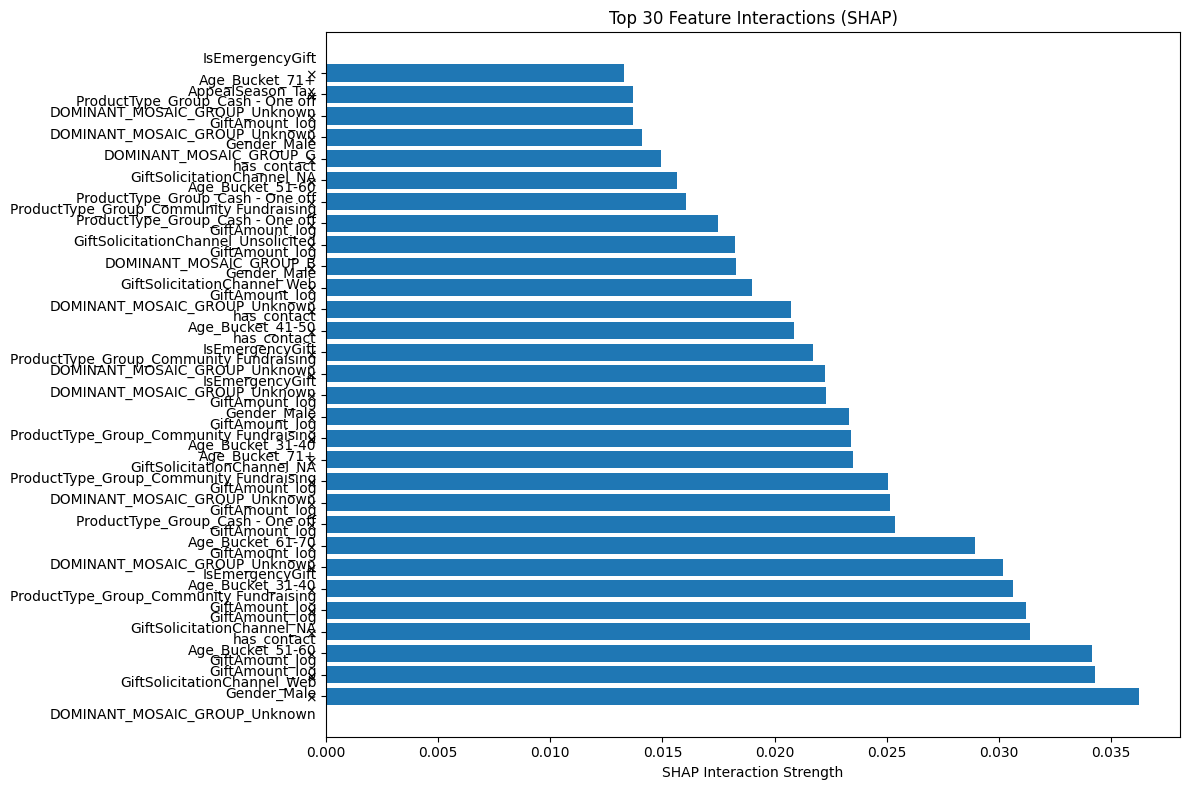

In [ ]:
import shap
from xgboost import XGBClassifier

def discover_interactions_with_shap(X_train, y_train, top_n=10):
    print("\n" + "=" * 60)
    print("SHAP analysis")
    print("=" * 60)


    model = XGBClassifier(
        max_depth=6,
        n_estimators=100,
        random_state=42
    )
    model.fit(X_train, y_train)

    sample_size = min(1000, len(X_train))
    X_sample = X_train.sample(sample_size, random_state=42)

    print(f"\caculate shap（sample size={sample_size}）...")
    explainer = shap.TreeExplainer(model)
    shap_interaction_values = explainer.shap_interaction_values(X_sample)


    interaction_matrix = np.abs(shap_interaction_values).mean(axis=0)

    np.fill_diagonal(interaction_matrix, 0)

    interactions = []
    n_features = len(X_train.columns)

    for i in range(n_features):
        for j in range(i+1, n_features):
            interactions.append({
                'feature1': X_train.columns[i],
                'feature2': X_train.columns[j],
                'interaction_strength': interaction_matrix[i, j]
            })

    interaction_df = pd.DataFrame(interactions).sort_values(
        'interaction_strength',
        ascending=False
    )

    print(f"\n=== Top {top_n} shap charateristic ===")
    print(interaction_df.head(top_n).to_string(index=False))

    plt.figure(figsize=(12, 8))
    top_pairs = interaction_df.head(top_n)

    y_pos = np.arange(len(top_pairs))
    plt.barh(y_pos, top_pairs['interaction_strength'])
    plt.yticks(y_pos, [
        f"{row['feature1']}\n×\n{row['feature2']}"
        for _, row in top_pairs.iterrows()
    ])
    plt.xlabel('SHAP Interaction Strength')
    plt.title(f'Top {top_n} Feature Interactions (SHAP)')
    plt.tight_layout()
    plt.savefig('shap_interactions.png', dpi=300)
    print("\n shap was printed")

    return interaction_df, model

interaction_df, model = discover_interactions_with_shap(
    X_train,
    y_train,
    top_n=30
)

# EDA

## Age & Gender

### Gender

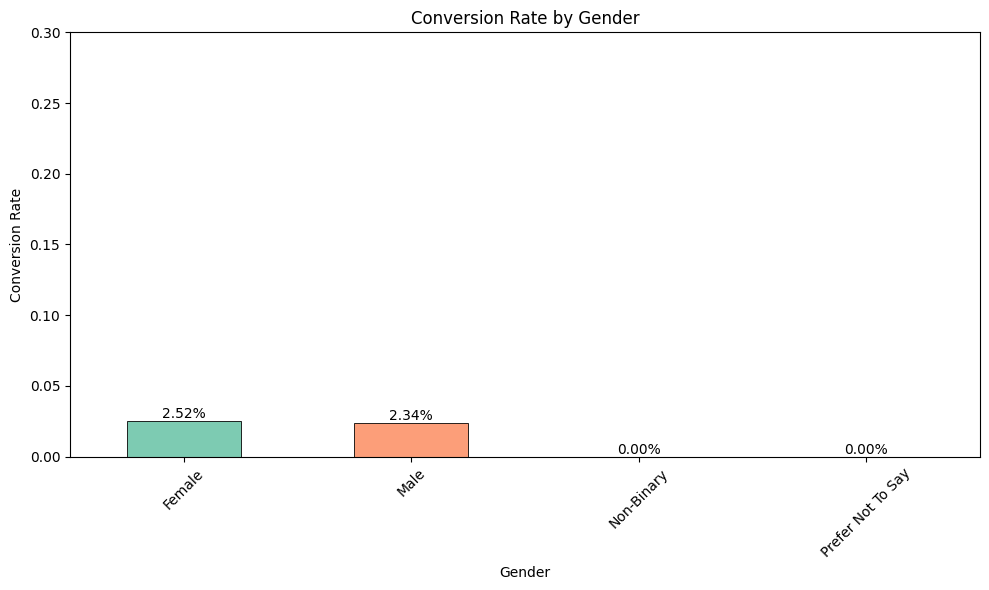

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for the color palette

total_counts = df_train['Gender'].value_counts()

converted_counts = df_train[df_train['ConvertedTo_RG_Within_6M'] == 1]['Gender'].value_counts()

conversion_rate = (converted_counts / total_counts).sort_index()

palette = sns.color_palette("Set2")

fig, ax = plt.subplots(figsize=(10,6))
conversion_rate.plot(
    kind='bar',
    ax=ax,
    color=palette,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.7
)


plt.title("Conversion Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45)
plt.ylim(0, 0.3)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2%}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('Gender_ConversionRate')
plt.show()

### Age

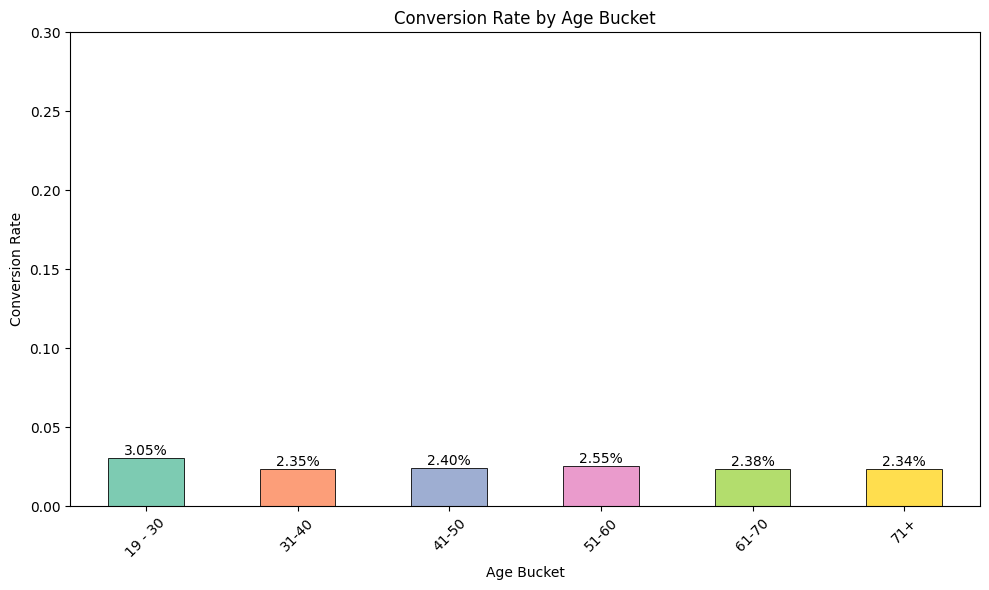

In [ ]:
import matplotlib.pyplot as plt


total_counts = df_train['Age_Bucket'].value_counts()

converted_counts = df_train[df_train['ConvertedTo_RG_Within_6M'] == 1]['Age_Bucket'].value_counts()
conversion_rate = (converted_counts / total_counts).sort_index()

fig, ax = plt.subplots(figsize=(10,6))
conversion_rate.plot(
    kind='bar',
    ax=ax,
    color=palette,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.7
)


plt.title("Conversion Rate by Age Bucket")
plt.xlabel("Age Bucket")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45)
plt.ylim(0, 0.3)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2%}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('Age_Bucket_ConversionRate')
plt.show()


### Combine

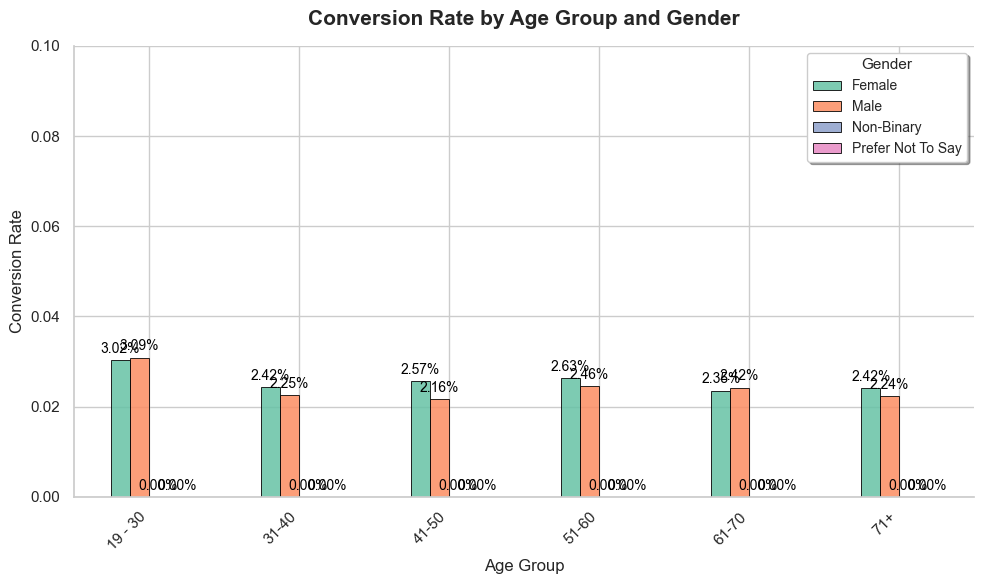

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df_train['ConvertedTo_RG_Within_6M'] = df_train['ConvertedTo_RG_Within_6M'].astype(int)

conversion_rate = (
    df_train.groupby(['Age_Bucket', 'Gender'])['ConvertedTo_RG_Within_6M']
    .mean()
    .unstack()
)

palette = sns.color_palette("Set2")

fig, ax = plt.subplots(figsize=(10,6))
conversion_rate.plot(
    kind='bar',
    ax=ax,
    color=palette,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.7
)

plt.title("Conversion Rate by Age Group and Gender", fontsize=15, weight='bold', pad=15)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Conversion Rate", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 0.1)
plt.legend(title="Gender", title_fontsize=11, fontsize=10, frameon=True, fancybox=True, shadow=True)

for container in ax.containers:
    ax.bar_label(container, labels=[f'{v*100:.2f}%' for v in container.datavalues],
                 padding=3, fontsize=10, color='black')

sns.despine()

plt.tight_layout()
plt.savefig('Age_Gender_ConversionRate_Beautified.png', dpi=300)
plt.show()


## Contact

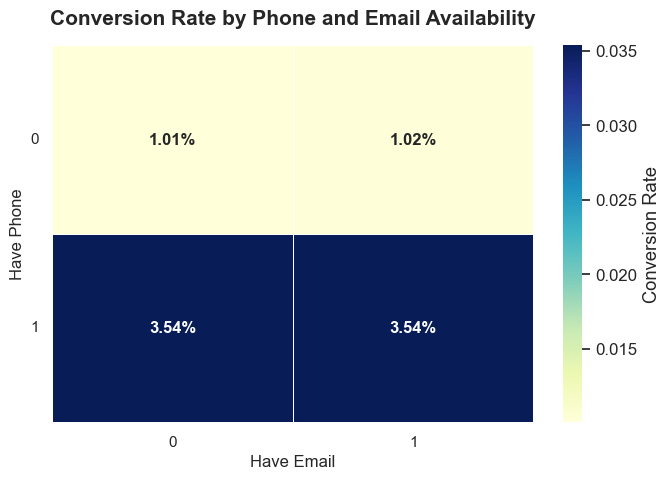

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

heatmap_data = (
    df_train
    .groupby(['Have_Phone', 'Have_Email'])['ConvertedTo_RG_Within_6M']
    .mean()
    .unstack()
)

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(7, 5))


ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2%",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 12, "weight": "bold"},
    cbar_kws={'label': 'Conversion Rate'}
)

plt.title("Conversion Rate by Phone and Email Availability", fontsize=15, weight='bold', pad=15)
plt.xlabel("Have Email", fontsize=12)
plt.ylabel("Have Phone", fontsize=12)

plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("contactable.png", dpi=300)
plt.show()


## Area

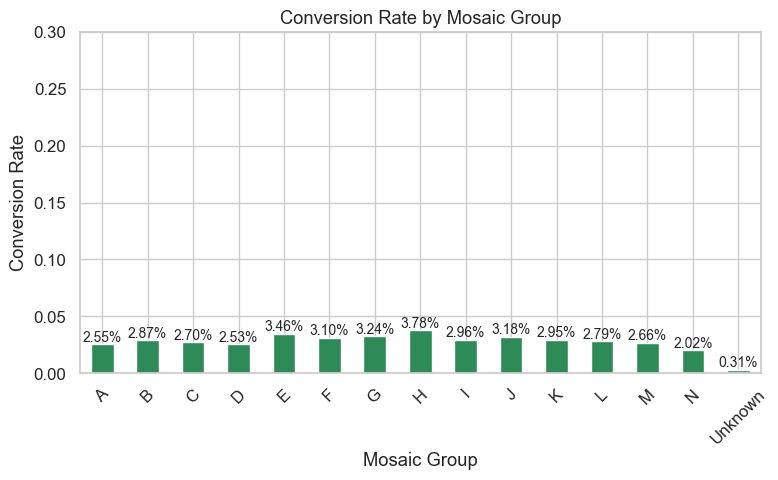

In [ ]:
import matplotlib.pyplot as plt

total_counts = df_train['DOMINANT_MOSAIC_GROUP'].value_counts()
converted_counts = df_train[df_train['ConvertedTo_RG_Within_6M'] == 1]['DOMINANT_MOSAIC_GROUP'].value_counts()
conversion_rate = (converted_counts / total_counts).sort_index()


plt.figure(figsize=(8,5))
ax = conversion_rate.plot(kind='bar', color='seagreen')

plt.title("Conversion Rate by Mosaic Group")
plt.xlabel("Mosaic Group")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45)
plt.ylim(0, 0.3)


for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2%}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('DOMINANT_MOSAIC_GROUP_ConversionRate')
plt.show()

## highvalue

In [ ]:
import matplotlib.pyplot as plt

total_counts = df_train["high_value"].value_counts()
converted_counts = df_train[df_train['ConvertedTo_RG_Within_6M'] == 1]["high_value"].value_counts()
conversion_rate = (converted_counts / total_counts).sort_index()

conversion_rate

# plt.figure(figsize=(8,5))
# ax = conversion_rate.plot(kind='bar', color='seagreen')

# plt.title("Conversion Rate by Mosaic Group")
# plt.xlabel("Mosaic Group")
# plt.ylabel("Conversion Rate")
# plt.xticks(rotation=45)
# plt.ylim(0, 0.3)


# for p in ax.patches:
#     height = p.get_height()
#     ax.annotate(f'{height:.2%}',
#                 (p.get_x() + p.get_width() / 2., height),
#                 ha='center', va='bottom', fontsize=10)

# plt.tight_layout()
# plt.savefig('DOMINANT_MOSAIC_GROUP_ConversionRate')
# plt.show()

high_value
0    0.021139
1    0.027757
Name: count, dtype: float64

## contact & highvalue

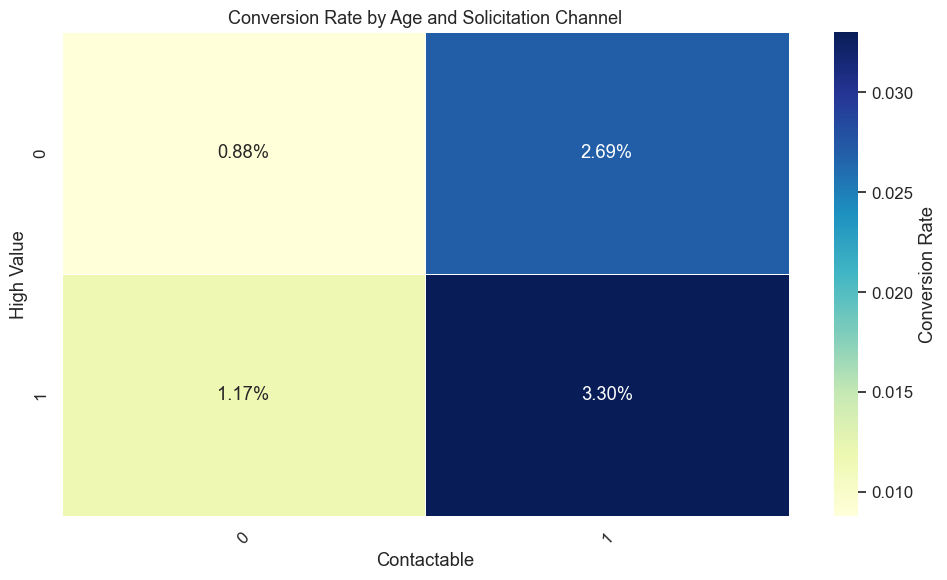

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

heatmap_data = (
    df_train
    .groupby(["high_value", "has_contact"])['ConvertedTo_RG_Within_6M']
    .mean()
    .unstack() )

plt.figure(figsize=(10,6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2%",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={'label': 'Conversion Rate'}
)

plt.title("Conversion Rate by Age and Solicitation Channel", fontsize=13)
plt.xlabel("Contactable")
plt.ylabel("High Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('hv_c.png')
plt.show()


## Channel

In [ ]:
channel_conversion = df_train.groupby("GiftSolicitationChannel")["ConvertedTo_RG_Within_6M"].mean().sort_values(ascending=False)
channel_conversion

GiftSolicitationChannel
TV               0.166667
DRTV             0.038462
Retail           0.037915
Web              0.029087
SMS              0.025641
General          0.025076
EDM              0.021626
Door to door     0.014833
Telemarketing    0.014737
F2F              0.011331
DM               0.005020
Unsolicited      0.002504
NA               0.001540
B2B              0.000000
Inserts          0.000000
Travel Trip      0.000000
Name: ConvertedTo_RG_Within_6M, dtype: float64

## Digital & High Value

In [ ]:
import matplotlib.pyplot as plt

total_counts = df_train["chan_digital"].value_counts()
converted_counts = df_train[df_train['ConvertedTo_RG_Within_6M'] == 1]["chan_digital"].value_counts()
conversion_rate = (converted_counts / total_counts).sort_index()

conversion_rate

chan_digital
0    0.004240
1    0.030112
Name: count, dtype: float64

In [ ]:
combo_conversion6 = (
    df_train.groupby(["high_value", "chan_digital"])["ConvertedTo_RG_Within_6M"]
    .agg(["mean", "count"])
    .reset_index()
    .sort_values(by="mean", ascending=False)
)
combo_conversion6.head(30)

,high_value,chan_digital,mean,count
3,1,1,0.033792,53652
1,0,1,0.026333,52254
2,1,0,0.004700,14042
0,0,0,0.003827,15678


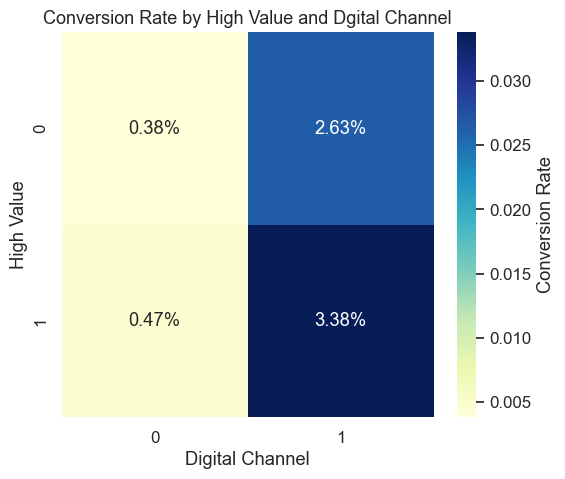

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


heatmap_data = (
    df_train
    .groupby(["high_value", "chan_digital"])['ConvertedTo_RG_Within_6M']
    .mean()
    .unstack()
)

plt.figure(figsize=(6,5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2%",
    cmap="YlGnBu",
    cbar_kws={'label': 'Conversion Rate'}
)

plt.title("Conversion Rate by High Value and Dgital Channel", fontsize=13)
plt.xlabel("Digital Channel")
plt.ylabel("High Value")
plt.savefig("hv_dc.png")
plt.show()


## Digital & Age

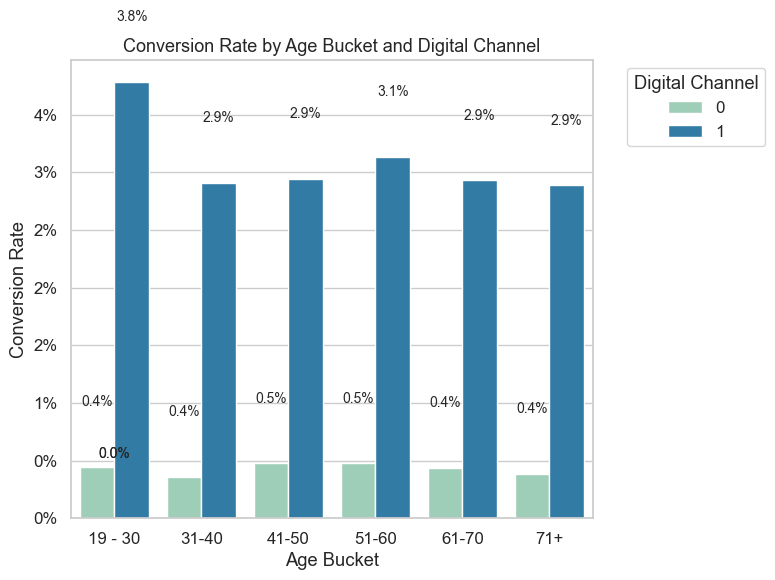

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

bar_data = (
    df_train
    .groupby(["Age_Bucket", "chan_digital"])['ConvertedTo_RG_Within_6M']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,6))
ax = sns.barplot(
    data=bar_data,
    x="Age_Bucket",
    y="ConvertedTo_RG_Within_6M",
    hue="chan_digital",
    palette="YlGnBu"
)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2.,
        height + 0.005,
        '{:.1%}'.format(height),
        ha="center", va="bottom", fontsize=10
    )

plt.title("Conversion Rate by Age Bucket and Digital Channel", fontsize=13)
plt.xlabel("Age Bucket")
plt.ylabel("Conversion Rate")
plt.legend(title="Digital Channel", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("AB_DC_bar.png")
plt.show()


## digital & emergency

In [ ]:
combo_conversion10 = (
    df_train.groupby(["has_contact", "IsEmergencyGift"])["ConvertedTo_RG_Within_6M"]
    .agg(["mean", "count"])
    .reset_index()
    .sort_values(by="mean", ascending=False)
)
combo_conversion10.head(30)

,has_contact,IsEmergencyGift,mean,count
2,1,0,0.036355,33668
3,1,1,0.026840,63487
1,0,1,0.011422,18735
0,0,0,0.008766,19736


## contact & digital

In [ ]:
combo_conversion9 = (
    df_train.groupby(["has_contact", "chan_digital",'IsEmergencyGift'])["ConvertedTo_RG_Within_6M"]
    .agg(["mean", "count"])
    .reset_index()
    .sort_values(by="mean", ascending=False)
)
combo_conversion9.head(30)

,has_contact,chan_digital,IsEmergencyGift,mean,count
6,1,1,0,0.041754,28117
7,1,1,1,0.036334,45274
3,0,1,1,0.012817,16150
2,0,1,0,0.009960,16365
4,1,0,0,0.009007,5551
5,1,0,1,0.003239,18213
0,0,0,0,0.002966,3371
1,0,0,1,0.002708,2585


# logistic Model

## baseline logistic


In [ ]:
categories_to_drop = ['DM', 'Travel Trip']
df_train = df_train[~df_train['GiftSolicitationChannel'].isin(categories_to_drop)].copy()

In [ ]:
base_train = df_train[['Gender','Age_Bucket','Have_Phone','Have_Email','IsEmergencyGift','Is_First_Gift','ProductType_Group','AppealSeason','GiftAmount', 'GiftSolicitationChannel','CampaignSubtype_Group','DOMINANT_MOSAIC_GROUP','ConvertedTo_RG_Within_6M']]
base_test_set = test[['Gender','Age_Bucket','Have_Phone','Have_Email','IsEmergencyGift','Is_First_Gift','ProductType_Group','AppealSeason','GiftAmount', 'GiftSolicitationChannel','CampaignSubtype_Group','DOMINANT_MOSAIC_GROUP']]

In [ ]:
base_train = pd.get_dummies(base_train, dummy_na=True, drop_first=True).fillna(0)
X_test = pd.get_dummies(base_test_set, dummy_na=True, drop_first=True).fillna(0)

In [ ]:
X = base_train.drop(columns='ConvertedTo_RG_Within_6M')
y = base_train['ConvertedTo_RG_Within_6M']

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
X = X.astype(float)
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                        Feature        VIF
16      ProductType_Group_Community Fundraising        inf
37  CampaignSubtype_Group_Community Fundraising        inf
35                  GiftSolicitationChannel_Web  88.810306
19                    AppealSeason_Non Seasonal  72.880814
29                   GiftSolicitationChannel_NA  18.722906
39         CampaignSubtype_Group_Regular Giving  14.582439
15             ProductType_Group_Cash - One off   8.616034
24         GiftSolicitationChannel_Door to door   7.882330
1                                    Have_Email   6.681729
27              GiftSolicitationChannel_General   6.501157
21                             AppealSeason_Tax   6.167611
0                                    Have_Phone   6.130640
8                              Age_Bucket_31-40   5.028978
30               GiftSolicitationChannel_Retail   4.593426
54                DOMINANT_MOSAIC_GROUP_Unknown   4.498434
34          GiftSolicitationChannel_Unsolicited   4.4966

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight

model = LogisticRegression(max_iter=10000, class_weight='balanced')

model.fit(X, y)

LogisticRegression(class_weight='balanced', max_iter=10000)

In [ ]:
from sklearn.metrics import classification_report

y_probs = model.predict_proba(X.astype(float))[:, 1]

y_train_pred = (y_probs > 0.63).astype(int)

print(classification_report(y, y_train_pred))


              precision    recall  f1-score   support

         0.0       0.98      0.81      0.89    129527
         1.0       0.04      0.35      0.08      3301

    accuracy                           0.80    132828
   macro avg       0.51      0.58      0.48    132828
weighted avg       0.96      0.80      0.87    132828



In [ ]:
import numpy as np
from sklearn.metrics import f1_score

y_proba = model.predict_proba(X.astype(float))[:, 1]


thresholds = np.arange(0, 1.01, 0.01)

f1_scores = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    f1 = f1_score(y, y_pred)
    f1_scores.append(f1)


best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"best threshold: {best_threshold:.2f}")
print(f"best f1 score {best_f1:.4f}")


best threshold: 0.63
best f1 score 0.0788


In [ ]:
# Align columns - crucial for consistent feature order
# Reindex the test set to match the columns of the training set
# Fill missing columns with 0
expected_cols = X.columns
X_test_aligned = X_test.reindex(columns=expected_cols, fill_value=0)

predictions = (model.predict_proba(X_test_aligned.astype(float))[:, 1] > 0.63).astype(int)
predictions

array([0, 0, 0, ..., 0, 1, 1])

In [ ]:
np.sum(predictions == 1)

np.int64(3007)

In [ ]:
submission = pd.DataFrame({'SupporterID': test['SupporterID'], 'ConvertedTo_RG_Within_6M': predictions})
submission.to_csv('baselog_submission.csv', index=False)

In [ ]:

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients_sorted = coefficients.sort_values(by='Coefficient', ascending=False)

print("Top 10 Positive Coefficients (Increase conversion likelihood):")
print(coefficients_sorted.head(10))


print("\n Top 10 Negative Coefficients (Decrease conversion likelihood):")
print(coefficients_sorted.tail(10))



Top 10 Positive Coefficients (Increase conversion likelihood):
                                 Feature  Coefficient
30        GiftSolicitationChannel_Retail     1.304435
32            GiftSolicitationChannel_TV     0.902060
0                             Have_Phone     0.632621
1                             Have_Email     0.490533
24  GiftSolicitationChannel_Door to door     0.433396
15      ProductType_Group_Cash - One off     0.352759
47               DOMINANT_MOSAIC_GROUP_H     0.335695
34   GiftSolicitationChannel_Unsolicited     0.243508
44               DOMINANT_MOSAIC_GROUP_E     0.242758
23          GiftSolicitationChannel_DRTV     0.236691

 Top 10 Negative Coefficients (Decrease conversion likelihood):
                                        Feature  Coefficient
53                      DOMINANT_MOSAIC_GROUP_N    -0.429085
16      ProductType_Group_Community Fundraising    -0.549057
37  CampaignSubtype_Group_Community Fundraising    -0.549057
18                       AppealSea

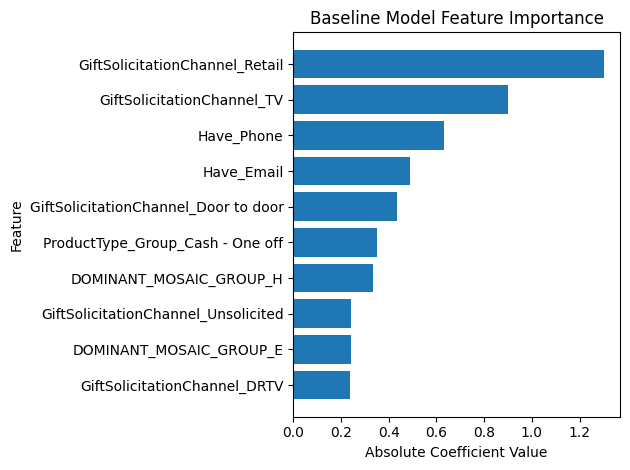

In [ ]:
features = base_train.drop(columns='ConvertedTo_RG_Within_6M').columns
# For Logistic Regression, use the absolute values of the coefficients as a measure of importance
importances = pd.Series((model.coef_[0]), index=features).sort_values()

plt.barh(range(len(importances[-10:])), importances[-10:], tick_label=importances.index[-10:])
plt.title('Baseline Model Feature Importance')
plt.xlabel('Absolute Coefficient Value'); plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('importances.png')

##logistic model feature

In [ ]:
train = df_train[['Male_young', 'Male_midage', 'Male_elder', 'Female_young', 'Female_midage', 'Female_midage', 'Female_elder', 'Highvalue_Digital', 'GiftAmount', 'has_contact', 'HighValue_has_contact', 'DOMINANT_MOSAIC_GROUP', 'ProductType_Group', 'AppealSeason','Digital_contact','young_digital','midage_digital','elder_digital','young_digital_contact','GiftSolicitationChannel','ConvertedTo_RG_Within_6M']]
test_set = test[['Male_young', 'Male_midage', 'Male_elder', 'Female_young', 'Female_midage', 'Female_midage', 'Female_elder', 'Highvalue_Digital', 'GiftAmount', 'has_contact', 'HighValue_has_contact', 'DOMINANT_MOSAIC_GROUP', 'ProductType_Group', 'AppealSeason', 'Digital_contact','young_digital','midage_digital','elder_digital','young_digital_contact','GiftSolicitationChannel']]

In [ ]:
train = pd.get_dummies(train, dummy_na=True, drop_first=True).fillna(0)
X_test = pd.get_dummies(test_set, dummy_na=True, drop_first=True).fillna(0)

In [ ]:
# Define X and y
X = train.drop(columns='ConvertedTo_RG_Within_6M')
y = train['ConvertedTo_RG_Within_6M']

In [ ]:
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# import pandas as pd
# X = X.astype(float)
# vif_data = pd.DataFrame()
# vif_data["Feature"] = X.columns
# vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# print(vif_data.sort_values(by="VIF", ascending=False))

KeyboardInterrupt: 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight

model = LogisticRegression(max_iter=10000, class_weight='balanced')

model.fit(X, y)

LogisticRegression(class_weight='balanced', max_iter=10000)

In [ ]:
from sklearn.metrics import classification_report

y_probs = model.predict_proba(X.astype(float))[:, 1]


y_train_pred = (y_probs > 0.63).astype(int)

print(classification_report(y, y_train_pred))

              precision    recall  f1-score   support

         0.0       0.98      0.78      0.87    129527
         1.0       0.05      0.45      0.09      3301

    accuracy                           0.77    132828
   macro avg       0.52      0.61      0.48    132828
weighted avg       0.96      0.77      0.85    132828



In [ ]:
from sklearn.metrics import classification_report


print(classification_report(y, y_train_pred))

              precision    recall  f1-score   support

         0.0       0.98      0.78      0.87    129527
         1.0       0.05      0.45      0.09      3301

    accuracy                           0.77    132828
   macro avg       0.52      0.61      0.48    132828
weighted avg       0.96      0.77      0.85    132828



In [ ]:
# Align columns - crucial for consistent feature order
# Reindex the test set to match the columns of the training set
# Fill missing columns with 0
expected_cols = X.columns
X_test_aligned = X_test.reindex(columns=expected_cols, fill_value=0)

predictions = (model.predict_proba(X_test_aligned.astype(float))[:, 1] > 0.63).astype(int)
predictions

array([0, 0, 0, ..., 0, 1, 1])

In [ ]:
probs = model.predict_proba(X_test.astype(float))[:, 1]
probs

array([0.33985452, 0.30941774, 0.52400054, ..., 0.33141151, 0.68877432,
       0.70188526])

In [ ]:
np.sum(predictions == 1)

np.int64(3424)

In [ ]:
submission = pd.DataFrame({'SupporterID': test['SupporterID'], 'ConvertedTo_RG_Within_6M': predictions})
submission.to_csv('log_submission.csv', index=False)

In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients_sorted = coefficients.sort_values(by='Coefficient', ascending=False)

print("Top 10 Positive Coefficients (Increase conversion likelihood):")
print(coefficients_sorted.head(10))


print("\n Top 10 Negative Coefficients (Decrease conversion likelihood):")
print(coefficients_sorted.tail(10))


Top 10 Positive Coefficients (Increase conversion likelihood):
                                Feature  Coefficient
11                      Digital_contact     1.009534
50  GiftSolicitationChannel_Unsolicited     0.840826
46       GiftSolicitationChannel_Retail     0.684796
48           GiftSolicitationChannel_TV     0.566674
43      GiftSolicitationChannel_General     0.440833
7                     Highvalue_Digital     0.388382
21              DOMINANT_MOSAIC_GROUP_H     0.376838
9                           has_contact     0.282478
18              DOMINANT_MOSAIC_GROUP_E     0.280470
30     ProductType_Group_Cash - One off     0.278630

 Top 10 Negative Coefficients (Decrease conversion likelihood):
                                    Feature  Coefficient
34                AppealSeason_Non Seasonal    -0.394085
6                              Female_elder    -0.407184
0                                Male_young    -0.499772
3                              Female_young    -0.502303
47  

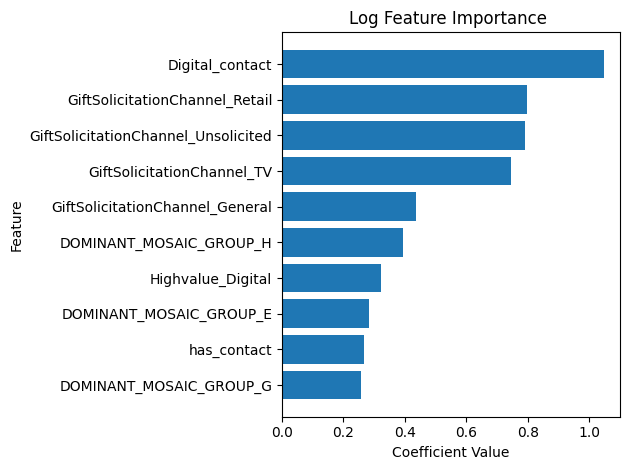

In [ ]:
features = train.drop(columns='ConvertedTo_RG_Within_6M').columns
# For Logistic Regression, use the absolute values of the coefficients as a measure of importance
importances = pd.Series((model.coef_[0]), index=features).sort_values()

plt.barh(range(len(importances[-10:])), importances[-10:], tick_label=importances.index[-10:])
plt.title('Log Feature Importance ')
plt.xlabel('Coefficient Value'); plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('Logimportances.png')

# SGDClassifier

In [112]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 132828 entries, 0 to 1780138
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SupporterID               132828 non-null  object 
 1   Age_Bucket                132828 non-null  object 
 2   Gender                    132828 non-null  object 
 3   PostCode                  108436 non-null  Int64  
 4   Have_Phone                132828 non-null  int64  
 5   Have_Email                132828 non-null  int64  
 6   Gift_ID                   132828 non-null  object 
 7   GiftDate                  132828 non-null  object 
 8   IsEmergencyGift           132828 non-null  int64  
 9   Is_First_Gift             132828 non-null  object 
 10  ProductType_Group         132828 non-null  object 
 11  GiftSolicitationChannel   132828 non-null  object 
 12  CampaignSubtype_Group     132828 non-null  object 
 13  AppealSeason              132828 non-null  objec

In [113]:
train = df_train[['Male_young', 'Male_midage', 'Male_elder', 'Female_young', 'Female_midage', 'Female_midage', 'Female_elder','Digital_Emergency', 'Highvalue_Digital', 'GiftAmount_log', 'has_contact', 'HighValue_has_contact', 'DOMINANT_MOSAIC_GROUP', 'ProductType_Group', 'AppealSeason','Digital_contact','young_digital','midage_digital','elder_digital','young_digital_contact','ConvertedTo_RG_Within_6M']]
test_set = test[['Male_young', 'Male_midage', 'Male_elder', 'Female_young', 'Female_midage', 'Female_midage', 'Female_elder','Digital_Emergency', 'Highvalue_Digital', 'GiftAmount_log', 'has_contact', 'HighValue_has_contact', 'DOMINANT_MOSAIC_GROUP', 'ProductType_Group', 'AppealSeason', 'Digital_contact','young_digital','midage_digital','elder_digital','young_digital_contact']]

In [114]:
train = pd.get_dummies(train, dummy_na=True, drop_first=True).fillna(0)
X_test = pd.get_dummies(test_set, dummy_na=True, drop_first=True).fillna(0)

In [115]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score)

def evaluate_preds(y_true,y_preds):
    """
    Performs evaluation comparison on y_true labels vs. y_pred labels
    on a classification
    """
    accuracy = accuracy_score(y_true,y_preds)
    precision = precision_score(y_true,y_preds)
    recall = recall_score(y_true,y_preds)
    f1 = f1_score(y_true,y_preds)
    metric_dict = {'accuracy': round(accuracy,2),
                   'precision': round(precision,2),
                   'recall': round(recall,2),
                   'f1': round(f1,2)}
    print(f'ACC: {accuracy * 100:2f}%')
    print(f'Precision: {precision:.2f}')
    print(f'Recall: {recall:.2f}')
    print(f'F1 score:{f1:.2f}')

    return metric_dict

In [116]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler
from sklearn.linear_model import SGDClassifier

np.random.seed(42)

X = train.drop(columns='ConvertedTo_RG_Within_6M',axis=1)
y = train['ConvertedTo_RG_Within_6M']

#Split the data
X_train,X_test,y_train,y_test = train_test_split(X,y,stratify=y,test_size=0.2)

clf = SGDClassifier()
clf.fit(X_train,y_train)

clf.score(X_test,y_test)

0.9751562147105323

In [117]:
from sklearn.metrics import classification_report

y_train_pred = clf.predict(X.astype(float))
# Calculate the classification report on the training data
print(classification_report(y, y_train_pred))

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99    129527
         1.0       0.00      0.00      0.00      3301

    accuracy                           0.98    132828
   macro avg       0.49      0.50      0.49    132828
weighted avg       0.95      0.98      0.96    132828



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Tuning parameter

In [118]:
# Import the SGDClssifier estimator calss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler
from sklearn.linear_model import SGDClassifier

#Setup random seed
np.random.seed(42)

#Make the data
X = train.drop(columns='ConvertedTo_RG_Within_6M',axis=1)
y = train['ConvertedTo_RG_Within_6M']

#Split the data
X_train,X_test,y_train,y_test = train_test_split(X,y,stratify=y,test_size=0.2)

# Instantiate SGDClassifier
clf = SGDClassifier(loss="log_loss",class_weight="balanced")
clf.fit(X_train,y_train)

#Evaluate the SGDClassifier
clf.score(X_test,y_test)

0.5024843785289468

In [119]:
from sklearn.metrics import classification_report

y_train_pred = clf.predict(X.astype(float))
# Calculate the classification report on the training data
print(classification_report(y, y_train_pred))

              precision    recall  f1-score   support

         0.0       0.99      0.49      0.66    129527
         1.0       0.04      0.83      0.08      3301

    accuracy                           0.50    132828
   macro avg       0.52      0.66      0.37    132828
weighted avg       0.97      0.50      0.64    132828



In [120]:
clf.predict(X_test)

array([1., 1., 0., ..., 0., 1., 1.])

In [121]:
y_preds = clf.predict(X_test)
np.mean(y_preds == y_test)

np.float64(0.5024843785289468)

In [122]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_preds)

0.5024843785289468

In [123]:
clf.predict(X_test)

array([1., 1., 0., ..., 0., 1., 1.])

In [124]:
from sklearn.model_selection import cross_val_score
cross_val_score(clf,X,y,cv=5)

array([0.80064744, 0.63728073, 0.46612211, 0.38513081, 0.79047619])

In [125]:
np.random.seed(42)

# Single training and test split score
clf_single_score = clf.score(X_test,y_test)

# Take the mean of 5-fold cross-validation score
clf_cross_val_score = np.mean(cross_val_score(clf,X,y,cv=5))

#Compare the two
clf_single_score, clf_cross_val_score

(0.5024843785289468, np.float64(0.5594968592546405))

In [126]:
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_predict
y_pred_cv = cross_val_predict(clf, X, y, cv=5)
print(classification_report(y, y_pred_cv))

              precision    recall  f1-score   support

         0.0       0.99      0.51      0.67    129527
         1.0       0.04      0.73      0.07      3301

    accuracy                           0.51    132828
   macro avg       0.51      0.62      0.37    132828
weighted avg       0.96      0.51      0.66    132828



### RandomSearchCV

In [127]:
import numpy as np
from sklearn.preprocessing import MaxAbsScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline


pipe = Pipeline([
    ("scale", MaxAbsScaler()),
    ("clf",   SGDClassifier(loss="log_loss",class_weight="balanced",
                            max_iter=3000, tol=1e-3,
                            early_stopping=True, n_iter_no_change=5,
                            random_state=42))
])

param_dist = {
    "clf__alpha":        [1e-5, 3e-5, 1e-4, 3e-4, 1e-3],
    "clf__penalty":      ["l2", "elasticnet"],
    "clf__l1_ratio":     [0.0, 0.15]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    pipe,param_distributions=param_dist,
    n_iter=10, scoring="average_precision",
    cv=cv, random_state=42, verbose=1, n_jobs=-1
)

rs.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('scale', MaxAbsScaler()),
                                             ('clf',
                                              SGDClassifier(class_weight='balanced',
                                                            early_stopping=True,
                                                            loss='log_loss',
                                                            max_iter=3000,
                                                            random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'clf__alpha': [1e-05, 3e-05, 0.0001,
                                                       0.0003, 0.001],
                                        'clf__l1_ratio': [0.0, 0.15],
                                        'clf__penalty': ['l2', 'elasticnet']},
                   random_state=42, scoring='average_precision', verbose=1)

In [128]:
# Make predictions with the best hyperparameters
rs_y_preds = rs.predict(X_test)

# Evaluate the predictions
rs_metrics = evaluate_preds(y_test,rs_y_preds)

ACC: 50.654973%
Precision: 0.04
Recall: 0.82
F1 score:0.08


In [129]:
rs.best_estimator_

Pipeline(steps=[('scale', MaxAbsScaler()),
                ('clf',
                 SGDClassifier(alpha=0.001, class_weight='balanced',
                               early_stopping=True, l1_ratio=0.0,
                               loss='log_loss', max_iter=3000,
                               penalty='elasticnet', random_state=42))])

In [142]:
import pandas as pd
import numpy as np

# 获取最优模型（包括标准化器和SGD分类器）
best_model = rs.best_estimator_

# 取出SGD分类器部分
sgd = best_model.named_steps['clf']

# 获取特征名称（保持和dummies对应）
feature_names = X_train.columns

# 提取系数
coef = sgd.coef_.flatten()

# 构建DataFrame查看结果
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef,
    'Abs_Coefficient': np.abs(coef) # Add absolute values for easier sorting later
})

# 显示正负影响最大的特征
print("Top positive coefficients:")
print(coef_df.sort_values(by='Coefficient', ascending=False).head(10))

print("\nTop negative coefficients:")
print(coef_df.sort_values(by='Coefficient', ascending=True).head(10))

Top positive coefficients:
                             Feature  Coefficient  Abs_Coefficient
12                   Digital_contact     1.055026         1.055026
31  ProductType_Group_Cash - One off     0.469175         0.469175
22           DOMINANT_MOSAIC_GROUP_H     0.414709         0.414709
19           DOMINANT_MOSAIC_GROUP_E     0.393981         0.393981
8                  Highvalue_Digital     0.372888         0.372888
24           DOMINANT_MOSAIC_GROUP_J     0.327501         0.327501
25           DOMINANT_MOSAIC_GROUP_K     0.256302         0.256302
10                       has_contact     0.253195         0.253195
21           DOMINANT_MOSAIC_GROUP_G     0.239859         0.239859
23           DOMINANT_MOSAIC_GROUP_I     0.176379         0.176379

Top negative coefficients:
                                    Feature  Coefficient  Abs_Coefficient
29            DOMINANT_MOSAIC_GROUP_Unknown    -1.395110         1.395110
32  ProductType_Group_Community Fundraising    -0.794427    

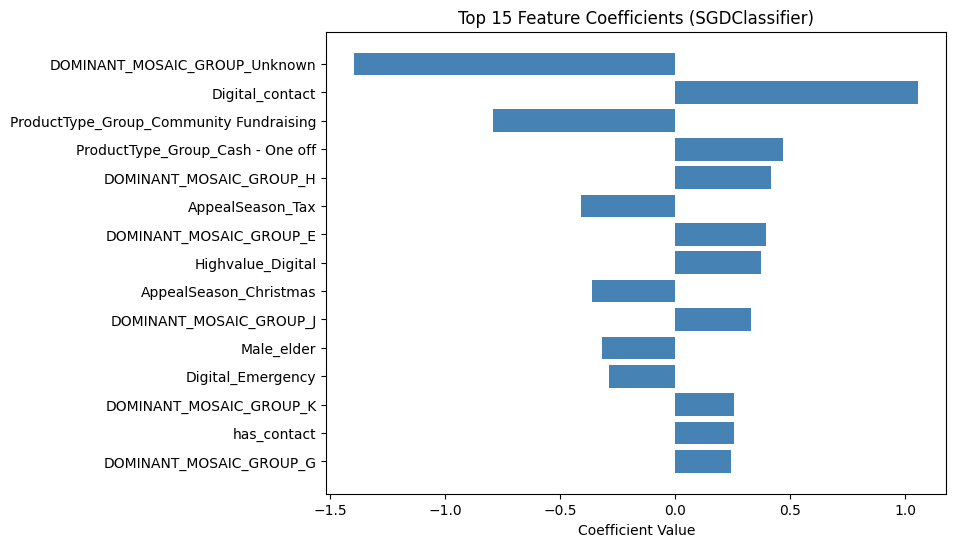

In [131]:
import matplotlib.pyplot as plt

top_features = coef_df.head(15)
plt.figure(figsize=(8,6))
plt.barh(top_features['Feature'], top_features['Coefficient'], color='steelblue')
plt.xlabel("Coefficient Value")
plt.title("Top 15 Feature Coefficients (SGDClassifier)")
plt.gca().invert_yaxis()
plt.show()


### GridSearchCV

In [132]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import average_precision_score, accuracy_score

pipe = Pipeline([
    ("scale", MaxAbsScaler()),
    ("rbf",   RBFSampler(random_state=1)),
    ("clf",   SGDClassifier(loss="log_loss", class_weight="balanced",
                            max_iter=3000, tol=1e-3,
                            early_stopping=True, n_iter_no_change=5,
                            random_state=42))
])

param_grid = {
    "rbf__gamma":        [0.3, 1.0],
    "rbf__n_components": [400, 800],
    "clf__alpha":        [1e-5, 1e-4, 1e-3],
    "clf__penalty":      ["l2", "elasticnet"]
}

gs_clf = GridSearchCV(pipe, param_grid, scoring="average_precision",
                  cv=cv, n_jobs=-1, verbose=1, refit=True)

gs_clf.fit(X_train, y_train)


Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scale', MaxAbsScaler()),
                                       ('rbf', RBFSampler(random_state=1)),
                                       ('clf',
                                        SGDClassifier(class_weight='balanced',
                                                      early_stopping=True,
                                                      loss='log_loss',
                                                      max_iter=3000,
                                                      random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__alpha': [1e-05, 0.0001, 0.001],
                         'clf__penalty': ['l2', 'elasticnet'],
                         'rbf__gamma': [0.3, 1.0],
                         'rbf__n_components': [400, 800]},
             scoring='average_precision', verbose=1)

In [133]:
gs_y_preds = gs_clf.predict(X_test)

# evaluate the predictions
gs_metrics = evaluate_preds(y_test,gs_y_preds)

GridSearchCV Model Metrics:
{'accuracy': 0.4364977791161635, 'precision': 0.036473179580202124, 'recall': 0.853030303030303, 'f1': 0.06995526838966203, 'roc_auc': np.float64(0.6394580990948628), 'average_precision': np.float64(0.03476401102535177)}


In [134]:
best_model = rs.best_estimator_

In [135]:
predictions = (best_model.predict_proba(X_test.astype(float))[:, 1] >= 0.74).astype(int)
predictions

array([0, 0, 0, ..., 0, 0, 0])

In [136]:
np.sum(predictions == 1)

np.int64(871)

In [137]:
X_test_raw = test.copy()

X_test_dm = pd.get_dummies(X_test_raw, dummy_na=True, drop_first=True).fillna(0)

expected_cols = best_model.feature_names_in_
X_test_used = X_test_dm.reindex(columns=expected_cols, fill_value=0).astype('float32')


proba_test = best_model.predict_proba(X_test_used)[:, 1]
pred_test  = (proba_test >= 0.74).astype(int)


In [138]:
ids = test.loc[X_test_used.index, 'SupporterID'].to_numpy()
submission = pd.DataFrame({
    'SupporterID': ids,
    'ConvertedTo_RG_Within_6M': pred_test
})
submission.to_csv('submission_randomsearch_sgd.csv', index=False)

In [139]:
sub = pd.read_csv('submission_randomsearch_sgd.csv')

In [140]:
sub['ConvertedTo_RG_Within_6M'].value_counts()

,count
ConvertedTo_RG_Within_6M,
0,14688
1,536


# xgb feature

In [72]:
categories_to_drop = ['DM', 'Travel Trip']
df_train = df_train[~df_train['GiftSolicitationChannel'].isin(categories_to_drop)].copy()

# drop since test set does not contain such terms

In [73]:
train = df_train[['Have_Phone','Have_Email','IsEmergencyGift','Is_First_Gift','ProductType_Group','AppealSeason','GiftAmount', 'GiftSolicitationChannel','CampaignSubtype_Group','ConvertedTo_RG_Within_6M']]
test_set = test[['Have_Phone','Have_Email','IsEmergencyGift','Is_First_Gift','ProductType_Group','AppealSeason','GiftAmount', 'GiftSolicitationChannel','CampaignSubtype_Group']]

In [74]:
train = pd.get_dummies(train, dummy_na=True, drop_first=True).fillna(0)
X_test = pd.get_dummies(test_set, dummy_na=True, drop_first=True).fillna(0)

In [75]:
# Define X and y
X = train.drop(columns='ConvertedTo_RG_Within_6M')
y = train['ConvertedTo_RG_Within_6M']

In [76]:
bool_cols = X.select_dtypes(bool).columns
X[bool_cols] = X[bool_cols].astype(int)

In [77]:
X_test[X_test.select_dtypes(bool).columns] = X_test.select_dtypes(bool).astype(int)

## XGBoost

In [78]:
!pip install xgboost

In [79]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_recall_curve
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n=== Fold {fold+1} ===")
    X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]

    # Compute positive weight for imbalance
    pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

    # Model
    model = XGBClassifier(
            n_estimators=1000, # Increased estimators
            max_depth=7, # Increased max_depth
            learning_rate=0.05, # Reduced learning rate
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=pos_weight, # Use calculated pos_weight
            eval_metric='logloss',
            random_state=42,
            use_label_encoder=False # Added to avoid warning
        )


=== Fold 1 ===

=== Fold 2 ===

=== Fold 3 ===

=== Fold 4 ===

=== Fold 5 ===


In [ ]:
model.fit(X_train.values, y_train.values)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [08:42:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_test_pred = (model.predict_proba(X_test.values)[:, 1] > 0.8).astype(int)
y_test_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
submission = pd.DataFrame({'SupporterID': test['SupporterID'], 'ConvertedTo_RG_Within_6M': y_test_pred})
submission.to_csv('xgb_submission.csv', index=False)

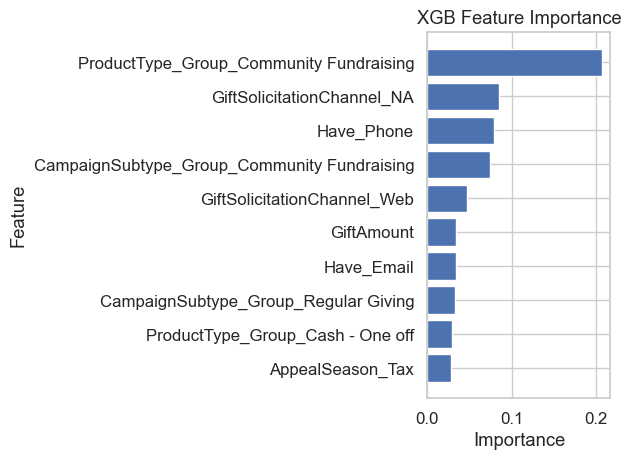

In [ ]:
features = train.drop(columns='ConvertedTo_RG_Within_6M').columns
importances = pd.Series(model.feature_importances_, index=features).sort_values()

plt.barh(range(len(importances[-10:])), importances[-10:], tick_label=importances.index[-10:])
plt.title('XGB Feature Importance')
plt.xlabel('Importance'); plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('importances.png')

# Decrsion Tree

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold

parameters = {
    'max_depth': np.arange(1, 20),
    'min_samples_leaf': np.arange(1, 100),
    'min_samples_split': np.arange(2, 20)
}

# Stratified CV to keep class ratio consistent
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Randomized search with F1 scoring
random_search = RandomizedSearchCV(
    DecisionTreeClassifier(criterion='entropy', random_state=0, class_weight='balanced'),
    parameters,
    n_iter=50,
    cv=cv,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

# Fit the model
random_search.fit(X, y)

,estimator,DecisionTreeC...andom_state=0)
,param_distributions,"{'max_depth': array([ 1, 2... 18, 19]), 'min_samples_leaf': array([ 1, 2..., 97, 98, 99]), 'min_samples_split': array([ 2, 3...8, 19])}"
,n_iter,50
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
model.predict_proba(X_test)

array([[0.57830966, 0.42169037],
       [0.6676158 , 0.33238426],
       [0.36694807, 0.63305193],
       ...,
       [0.46172196, 0.53827804],
       [0.39784515, 0.60215485],
       [0.24437171, 0.7556283 ]], shape=(15224, 2), dtype=float32)

In [ ]:
y_pred_binary = (model.predict_proba(X_test) > 0.9).astype(int)

In [ ]:
np.sum(y_pred_binary == 1)

np.int64(3740)

In [ ]:
# submission = pd.DataFrame({'SupporterID': test['SupporterID'], 'ConvertedTo_RG_Within_6M': y_pred_binary})
# submission.to_csv('tree_submission.csv', index=False)

# Random forest

### tune version

In [ ]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

parameters = {
    'n_estimators': [1,100,2],
    'max_depth': np.arange(3, 15),
    'min_samples_split': np.arange(2, 10),
    'min_samples_leaf': np.arange(1, 20),
    'max_features': ['sqrt', 'log2', 0.3, 0.5, None]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=0,
        class_weight='balanced',
        n_jobs=-1
    ),
    parameters,
    n_iter=50,
    cv=cv,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

model = random_search.fit(X,y)
best_model = random_search.best_estimator_

In [ ]:
model.predict(X_test)

array([0, 0, 1, ..., 1, 1, 1], shape=(15224,))

In [ ]:
y_pred_binary = (model.predict(X_test) >= 0.08).astype(int)
y_pred_binary

array([0, 0, 1, ..., 1, 1, 1], shape=(15224,))

In [ ]:
np.sum(y_pred_binary == 1)

np.int64(7133)

In [ ]:
# submission = pd.DataFrame({'SupporterID': test['SupporterID'], 'ConvertedTo_RG_Within_6M': y_pred_binary})
# submission.to_csv('rf_submission.csv', index=False)